In [26]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2,3"  
# os.environ["CUDA_VISIBLE_DEVICES"] = "2,3"  
from torch import nn


import numpy as np
 
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer  
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt  
import torch.nn.functional as F
import gc
import re
import copy

from tqdm import tqdm

import JCBScope_utils

# Move to GPU with optimal dtype
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = "cpu"

from matplotlib.colors import Normalize as Norm, LogNorm as Log_Norm

### Text-based visualization with colored boxes (like highlighted sentence)
from IPython.display import HTML, display
import matplotlib.colors as mcolors
import matplotlib as mpl


### Load models

In [27]:
# Deep clean CUDA GPU memory
torch.cuda.empty_cache()
torch.cuda.ipc_collect()
gc.collect()  



2488

In [28]:
# Load the tokenizer and model

model_name = "meta-llama/Llama-3.2-1B"
# model_name = "meta-llama/Llama-3.2-3B"
# model_name = "meta-llama/Llama-2-7b-chat-hf"

if device == "cpu":
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(model_name)
    model = model.to(device)
else:
    tokenizer = AutoTokenizer.from_pretrained(model_name, device_map="auto")
    model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto")
    
model.eval()

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 2048)
    (layers): ModuleList(
      (0-15): 16 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=512, bias=False)
          (v_proj): Linear(in_features=2048, out_features=512, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (up_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (down_proj): Linear(in_features=8192, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (ro

In [29]:
# Hutchinson trace via finite-diff JVP: tr(J^T Fx J) = E_z[(Jz)^T Fx (Jz)]
n_hutchinson_samples = 4
# n_hutchinson_samples = 1
eps_finite_diff = 1e-3  # perturbation scale for Jz ≈ (f(r+εz)-f(r))/ε
Temperature_scope = True

### Set input strings

In [30]:
front_pad = 2
back_pad = 0

system_prompt = ""

In [31]:
### Pad inputs with BOS tokens
front_pad = 2

### Dante
# string = "Italiano: Ma quando tu sarai nel dolce mondo, priegoti ch'a la mente altrui mi rechi: English: But when you have returned to the sweet world, I pray you bring me to men's memory"

### Trilingual translations
# string = "Italian: Buon pomeriggio, i miei colleghi ricercatori. English: Good afternoon, my fellow researchers"
string = "German: Dies ist ein Aufsatz über kausale Zuschreibung. English: This is a paper on causal attribution"
# string = "French: Nous l'appelons lentille jacobienne. English: We call it Jacobian Scope"

### Skip delimiters for time-series data
skip_delimiters = False

In [32]:
sys_prompt_tokens = tokenizer(system_prompt, add_special_tokens=False)["input_ids"]

sys_token_len = len(sys_prompt_tokens)

# Get special tokens if available
bos_token_id = tokenizer.bos_token_id if tokenizer.bos_token_id is not None else tokenizer.cls_token_id
eos_token_id = tokenizer.eos_token_id if tokenizer.eos_token_id is not None else tokenizer.sep_token_id

# Prepare input: pad both ends with special tokens
input_ids_list = []

# Pad the front
if bos_token_id is not None:
    input_ids_list += [bos_token_id] * front_pad

# Add system prompt
input_ids_list += sys_prompt_tokens
# Main tokens
input_ids_list += tokenizer(string, add_special_tokens=False)["input_ids"]

# Pad the back
if eos_token_id is not None:
    input_ids_list += [eos_token_id] * back_pad

input_ids = torch.tensor([input_ids_list], dtype=torch.long).to(model.device)
attention_mask = torch.ones_like(input_ids)

print("input_ids:", input_ids)
print("vocab size:", model.config.vocab_size)
assert input_ids.max() < model.config.vocab_size

seq_len = input_ids.size(1)

# Optional: print tokens
for i, tok in enumerate(input_ids[0]):
    print(i, tok.item(), repr(tokenizer.decode(tok.item(), skip_special_tokens=False)))

decoded_tokens = [tokenizer.decode(token_id.item(), skip_special_tokens=True) for token_id in input_ids[0]]

print(decoded_tokens)


input_ids: tensor([[128000, 128000,  33179,     25,  24934,   6127,   4466,  26798,     82,
          20786,  14104,    597,  12119,   1604,   1901,  52178,  76499,     13,
           6498,     25,   1115,    374,    264,   5684,    389,  59557,  63124]])
vocab size: 128256
0 128000 '<|begin_of_text|>'
1 128000 '<|begin_of_text|>'
2 33179 'German'
3 25 ':'
4 24934 ' Dies'
5 6127 ' ist'
6 4466 ' ein'
7 26798 ' Auf'
8 82 's'
9 20786 'atz'
10 14104 ' über'
11 597 ' k'
12 12119 'aus'
13 1604 'ale'
14 1901 ' Z'
15 52178 'usch'
16 76499 'reibung'
17 13 '.'
18 6498 ' English'
19 25 ':'
20 1115 ' This'
21 374 ' is'
22 264 ' a'
23 5684 ' paper'
24 389 ' on'
25 59557 ' causal'
26 63124 ' attribution'
['', '', 'German', ':', ' Dies', ' ist', ' ein', ' Auf', 's', 'atz', ' über', ' k', 'aus', 'ale', ' Z', 'usch', 'reibung', '.', ' English', ':', ' This', ' is', ' a', ' paper', ' on', ' causal', ' attribution']


In [33]:
### Set which tokens to perform gradients on
### Skip comma delimiters

if skip_delimiters:
    grad_idx = [idx for idx in range(front_pad+sys_token_len,len(decoded_tokens),2)]
else:
    ### all positions
    grad_idx = [idx for idx in range(front_pad+sys_token_len,len(decoded_tokens),1)]

print(grad_idx)

[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26]


### Construct backprop variables

In [34]:
embedding_layer = model.get_input_embeddings()
d_model = embedding_layer.embedding_dim

residual = nn.Parameter(torch.zeros(len(grad_idx), d_model, device=model.device))
presence = torch.ones(len(decoded_tokens), 1, device=model.device)


### Customize forward function

In [35]:
forward_pass = JCBScope_utils.customize_forward_pass(model, residual, presence, input_ids, grad_idx, attention_mask)

In [36]:
### Hutchinson probes (Rademacher ±1) for finite-diff JVP
d_model = residual.shape[-1]
torch.manual_seed(42)
hutch_probes = (torch.randint(0, 2, (n_hutchinson_samples, d_model), device=residual.device) * 2 - 1).to(residual.dtype)

### Fast Fisher Trace: Hutchinson via Finite-Diff JVP

We approximate $\operatorname{tr}(J_\tau^\top F_x J_\tau)$ per token using Hutchinson's estimator:
$\operatorname{tr}(J^\top F_x J) = \mathbb{E}_z \left[ (Jz)^\top F_x (Jz) \right]$ for $z \sim$ Rademacher $\pm 1$.

**Finite-diff JVP:** $J_\tau z \approx \frac{\mathrm{hidden}(r + \epsilon \cdot \mathrm{perturb}) - \mathrm{hidden}(r)}{\epsilon}$, where $\mathrm{perturb}$ is zero except at token $\tau$ where it equals $z$. 
Batches all $k$ Hutchinson directions per token into one forward pass.

**Complexity vs full Fisher:**

| Method | Passes | Notes |
|--------|--------|-------|
| **Finite-diff** | $O(T \cdot k)$ forwards | $T$ = n_tokens, $k$ = n_hutchinson_samples (~25–50). No backward passes. |
| **Full Fisher (exact)** | $O(d)$ backwards | One backward gives $\partial \text{loss}/\partial \text{residual}$ for all tokens. $d$ basis outputs suffice; $d$ = 2048. |


#### Hutchinson identity

For any matrix **A**, $\operatorname{tr}(A) = \mathbb{E}_z[z^\top A z]$ when $z \sim \{\pm 1\}^d$ (Rademacher) or $\mathbb{E}[zz^\top] = I$.

**Per-token Fisher info:** $F_\tau = J_\tau^\top F_x J_\tau$. Hutchinson: $\operatorname{tr}(F_\tau) = \mathbb{E}_z[(J_\tau z)^\top F_x (J_\tau z)]$.

**Algorithm:** For each sample $z$: (1) Compute $\mathbf{v} = J_\tau z$ via finite-diff; (2) $\mathbf{v}^\top F_x \mathbf{v}$; (3) average over $k$ samples. Typically 20–50 samples suffice.

In [37]:
# Finite-diff JVP computed in cell below

In [38]:
import time

loss_position = grad_idx[-1] - 1

if Temperature_scope:
    if residual.grad is not None:
        residual.grad = None
    tic = time.time()
    loss, logits = forward_pass(loss_position=loss_position, hidden_norm_as_loss=True)
    forward_toc = time.time()
    print(f"Time taken for hidden_norm_as_loss forward: {forward_toc - tic:.3f}s")
    temperature_grads = torch.autograd.grad(loss, residual, retain_graph=True)[0]
    print(f"Time taken for hidden_norm_as_loss grad: {time.time() - forward_toc:.3f}s")
else:
    _, logits = forward_pass(loss_position=loss_position)

# Finite-diff JVP: J_τ z = (hidden(r+ε·perturb) - hidden(r))/ε
# Batches all Hutchinson directions per token into one forward pass
hidden_base = forward_pass(loss_position=loss_position, return_hidden=True)
_, logits = forward_pass(loss_position=loss_position)  # logits for Fx
hutchinson_Jz_all = torch.zeros(residual.shape[0], n_hutchinson_samples, d_model, device=residual.device, dtype=residual.dtype)
batch_tic = time.time()
for tau in tqdm(range(residual.shape[0]), desc="Finite-diff JVP"):
    perturb = torch.zeros(n_hutchinson_samples, residual.shape[0], d_model, device=residual.device, dtype=residual.dtype)
    perturb[:, tau, :] = hutch_probes
    r_batch = residual.unsqueeze(0) + eps_finite_diff * perturb
    hidden_pert = forward_pass(loss_position=loss_position, residual_batch=r_batch, return_hidden=True)
    Jz = (hidden_pert - hidden_base.unsqueeze(0)) / eps_finite_diff
    hutchinson_Jz_all[tau] = Jz.detach()
print(f"Time for finite-diff JVP: {time.time() - batch_tic:.2f}s")


Time taken for hidden_norm_as_loss forward: 0.608s
Time taken for hidden_norm_as_loss grad: 0.499s


Finite-diff JVP: 100%|██████████| 25/25 [00:09<00:00,  2.75it/s]

Time for finite-diff JVP: 9.09s


In [39]:
print(f"hutchinson_Jz_all shape: {hutchinson_Jz_all.shape}")

hutchinson_Jz_all shape: torch.Size([25, 4, 2048])


In [40]:
# (Full Jacobian path removed; using finite-diff Hutchinson only)

### Compute FIM from Jacobian

In [41]:
import torch
import torch.nn.functional as F

def fisher_hidden_from_logits_and_W(logits_t, W, chunk_size=8192):
    """
    logits_t: [V]
    W:        [V, d]
    returns:  Fx [d, d] = W^T (Diag(p) - p p^T) W
    """
    if logits_t.ndim != 1:
        raise ValueError(f"logits_t must be 1D [V], got {tuple(logits_t.shape)}")
    if logits_t.numel() != W.shape[0]:
        raise ValueError(f"logits_t has {logits_t.numel()} entries but W has vocab {W.shape[0]}")

    p = F.softmax(logits_t, dim=-1).to(dtype=W.dtype)  # [V]

    V, d = W.shape
    S  = torch.zeros(d, d, device=W.device, dtype=W.dtype)  # sum_i p_i w_i w_i^T
    mu = torch.zeros(d,   device=W.device, dtype=W.dtype)   # sum_i p_i w_i

    for i in range(0, V, chunk_size):
        Wi = W[i:i+chunk_size]                 # [c, d]
        pi = p[i:i+chunk_size].unsqueeze(1)    # [c, 1]
        Ww = Wi * pi                           # [c, d]

        S  += Wi.T @ Ww
        mu += Ww.sum(dim=0)

    return S - torch.outer(mu, mu)

lm_head = JCBScope_utils.get_lm_head(model)
W = lm_head.weight.to(model.device)  # [V, 2048]

t = loss_position
logits_t = logits[t].to(model.device)  # [V]  (your fix)

with torch.no_grad():
    Fx = fisher_hidden_from_logits_and_W(logits_t, W, chunk_size=8192)  # [2048,2048]

# Hutchinson from finite-diff Jz: tr(J^T Fx J) = E_z[(Jz)^T Fx (Jz)]
# hutchinson_Jz_all: [n_tokens, n_samples, d_model]
g = hutchinson_Jz_all.to(Fx.device, dtype=Fx.dtype)
FxJz = g @ Fx  # [n_tokens, n_samples, d_model]
quad = (FxJz * g).sum(dim=-1)  # [n_tokens, n_samples] = (Jz)^T Fx (Jz) per sample
F_all_trace = quad.mean(dim=1).cpu().numpy()
print(f"Fisher trace (finite-diff JVP, tr(J^T Fx J)): shape {F_all_trace.shape}")


Fisher trace (finite-diff JVP, tr(J^T Fx J)): shape (25,)


In [42]:
# Deep clean CUDA GPU memory
torch.cuda.empty_cache()
torch.cuda.ipc_collect()
gc.collect()  


0

In [43]:
# spectrum_per_token = None

In [44]:
temperature_mag_per_token = temperature_grads.norm(dim=-1).detach().cpu()

In [45]:
def plotter(grad_magnitude, plot_title):
    print(plot_title)
    log_color = False
    exclude_target = 0
    cmap = plt.get_cmap('Blues')

    if exclude_target:
        optimized_tokens = [decoded_tokens[idx] for idx in grad_idx][:-1]
    else: 
        optimized_tokens = [decoded_tokens[idx] for idx in grad_idx]

    tick_label_text = optimized_tokens.copy()
                
    # Normalize grad_magnitude for color mapping
    log_norm = Log_Norm(vmin=grad_magnitude.min(), vmax=grad_magnitude.max())
    norm = Norm(vmin=grad_magnitude.min(), vmax=grad_magnitude.max())


    bar_idx = grad_idx.index(loss_position+1)

    if log_color:
        colors = cmap(log_norm(grad_magnitude))
    else:
        colors = cmap(norm(grad_magnitude))

    # Build HTML with colored boxes around each word, using bold font
    def rgba_to_css(rgba):
        """Convert matplotlib RGBA to CSS rgba string"""
        return f"rgba({int(rgba[0]*255)}, {int(rgba[1]*255)}, {int(rgba[2]*255)}, {rgba[3]:.2f})"

    def get_text_color(bg_rgba):
        """Return white or black text based on background luminance"""
        luminance = 0.299 * bg_rgba[0] + 0.587 * bg_rgba[1] + 0.114 * bg_rgba[2]
        return "white" if luminance < 0.5 else "black"

    html_parts = []
    for i, (token, color) in enumerate(zip(tick_label_text, colors)):
        bg_color = rgba_to_css(color)
        text_color = get_text_color(color)
        
        # Special styling for target token
        if i == bar_idx:
            # bg_color = "black"
            bg_color = "red"
            text_color = "white"
        
        # Clean up token display (remove leading space for display but keep for meaning)
        # display_token = token if token.strip() else "·"  # show dot for whitespace-only tokens
        # Show dot for tokens that are purely whitespace, but do not remove leading space otherwise
        # display_token = "1"+token 
        display_token = token 
        # print(display_token)
        
        html_parts.append(
            f'<span style="'
            f'background-color: {bg_color}; '
            f'color: {text_color}; '
            # f'padding: 0px 9px; '
            f'padding: 0px 0px; '
            # f'margin: 2px; '
            f'margin: 0px; '
            # f'border-radius: 8px; '
            f'border-radius: 0px; '
            f'font-family: monospace; '
            f'font-size: 16px; '
            f'display: inline-block; '
            f'font-weight: bold;'   # <-- bold font here
            # f'">{display_token}</span>'
            # To prevent collapsing of white spaces when displaying the token—including leading spaces—we can use CSS 'white-space: pre' so all spaces are rendered as-is.
            # This ensures that tokens like ' am' keep their leading space in the browser.
            f'white-space: pre;">{display_token}</span>'
        )

    # === OPTION A: HTML display with fixed width ===
    html_str = f'''
    <div style="
        background: white; 
        padding: 20px; 
        border-radius: 8px; 
        line-height: 2.2;
        width: 550px;
        # width: 1100px;
    ">
        {"".join(html_parts)}
    </div>
    '''
    display(HTML(html_str))


    # Adjust the figure size to better fit the colorbar and avoid cutoff
    fig_bar, ax_bar = plt.subplots(figsize=(0.4, 2.2), dpi=150)
    fig_bar.subplots_adjust(left=0.3, right=0.7, bottom=0.1, top=0.9)

    cbar = mpl.colorbar.ColorbarBase(
        ax_bar,
        cmap=cmap,
        norm=log_norm if log_color else norm,
        orientation='vertical'
    )
    # if normalize == True:
    #     cbar.set_label('Normalized influence', fontsize=12)    
    # else:
    #     cbar.set_label('Influence', fontsize=14, fontweight='bold')
    cbar.ax.tick_params(labelsize=10)
    cbar.ax.yaxis.set_ticks_position('left')
    cbar.ax.yaxis.set_label_position('left')
    plt.show()


Fisher Scope


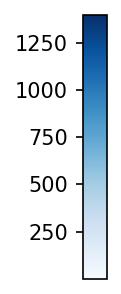

In [46]:
grad_magnitude = F_all_trace 
plot_title = "Fisher Scope"

plotter(grad_magnitude, plot_title)


Temperature Scope


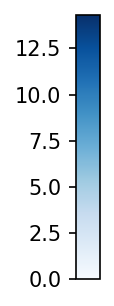

In [47]:
grad_magnitude = temperature_mag_per_token
plot_title = "Temperature Scope"

plotter(grad_magnitude, plot_title)